# Optical Depth and Contribution Analysis

After building and running forward models in [Transmission spectrum basics](https://escience-taurex.github.io/taurex3/examples/03_transmission_basics.html), [Emission spectrum basics](https://escience-taurex.github.io/taurex3/examples/04_emission_basics.html), [Cloud models](https://escience-taurex.github.io/taurex3/examples/05_clouds.html), and [Inspecting profiles](https://escience-taurex.github.io/taurex3/examples/06_inspecting_profiles.html), we now look inside them. A spectrum is the integrated result of opacity and temperature at every atmospheric layer, and this notebook unpacks that by inspecting the optical-depth cube and the per-contribution spectra that TauREx tracks internally.

Two core questions become answerable here:
- **Where** in the atmosphere does each wavelength channel become opaque?
- **Which contribution** — absorption, CIA, Rayleigh, or clouds — dominates a given spectral region?

These diagnostics are invaluable when a spectrum looks unexpected, and they will make the retrieval results in [Fitting parameters and retrievals](https://escience-taurex.github.io/taurex3/examples/10_retrievals.html) easier to interpret. More information about forward-model contributions is [here](../user/taurex/models.rst).

## Data Note

This notebook uses the opacity files set up in [Setup and opacity data](https://escience-taurex.github.io/taurex3/examples/01_setup_and_data.html). TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com).

In [1]:
from _shared import build_transmission_model

context = build_transmission_model(include_cia=False, include_rayleigh=True, download=False)
tm = context['tm']
wngrid, rprs, tau, _ = tm.model()
wlgrid = 10000 / wngrid[::-1]
tau = tau[..., ::-1]

print(f'Spectrum shape: {rprs.shape}')
print(f'Optical-depth shape: {tau.shape}')

Spectrum shape: (76744,)
Optical-depth shape: (100, 76744)


## Optical-Depth Map

The `model()` call returns a 2D optical-depth array indexed by atmospheric layer and wavelength bin. Because the native wavelength grid has tens of thousands of points, coarse-binning the wavelength axis before plotting reveals the pressure structure clearly without visual noise.

Text(0, 0.5, 'Atmospheric layer index')

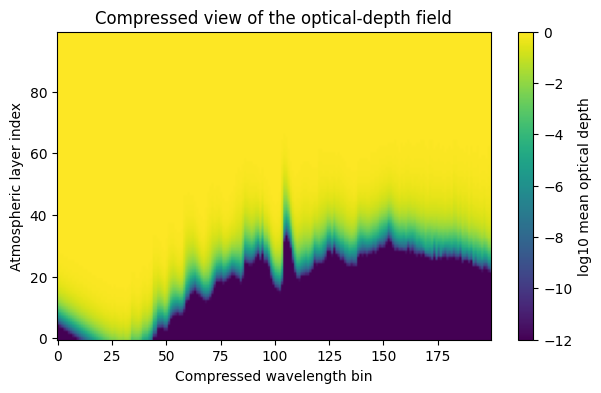

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def compress_wavelength_axis(optical_depth, bins=200):
    n_bins = min(bins, optical_depth.shape[1])
    chunks = np.array_split(optical_depth, n_bins, axis=1)
    return np.column_stack([chunk.mean(axis=1) for chunk in chunks])

mean_tau = compress_wavelength_axis(tau)

plt.figure(figsize=(7, 4))
plt.imshow(np.log10(np.clip(mean_tau, 1e-12, None)), aspect='auto', origin='lower')
plt.colorbar(label='log10 mean optical depth')
plt.title('Compressed view of the optical-depth field')
plt.xlabel('Compressed wavelength bin')
plt.ylabel('Atmospheric layer index')

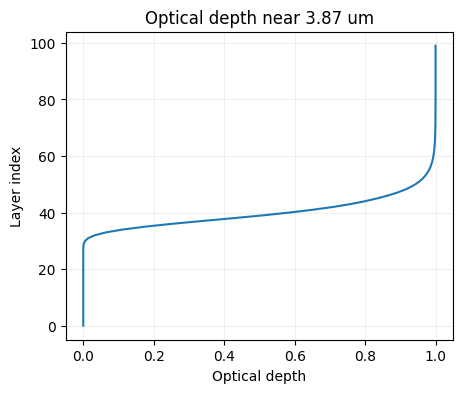

In [3]:
mid_wavelength = wlgrid[len(wlgrid) // 2]
mid_profile = tau[:, len(wlgrid) // 2]

plt.figure(figsize=(5, 4))
plt.plot(mid_profile, range(len(mid_profile)))
plt.xlabel('Optical depth')
plt.ylabel('Layer index')
plt.title(f'Optical depth near {mid_wavelength:.2f} um')
plt.grid(alpha=0.2)

## Isolating a Single Contribution

`model_full_contrib()` returns the spectrum decomposed by contribution. Comparing one contribution's spectrum against the total immediately shows whether it is sculpting the continuum, sharpening particular features, or barely contributing.

This per-contribution view is especially useful before setting up a retrieval: contributions with negligible spectral impact are poor candidates for free parameters. More information about contribution names and model syntax is [here](../user/taurex/models.rst).

Isolated contribution tau shape: (100, 76744)


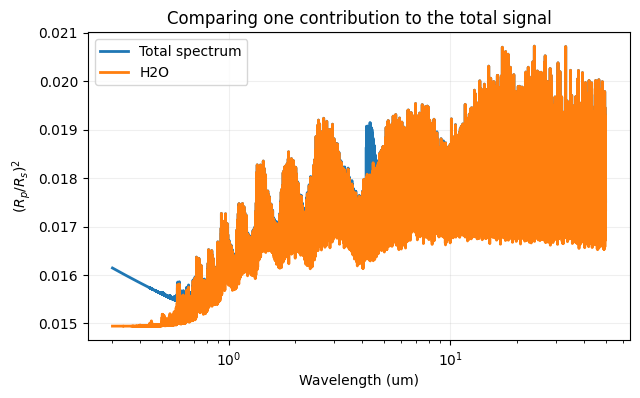

In [4]:
_, contribs = tm.model_full_contrib()
absorption = contribs['Absorption']
label, abs_rprs, abs_tau, _ = absorption[0]

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, rprs[::-1], label='Total spectrum', lw=2)
plt.plot(wlgrid, abs_rprs[::-1], label=label, lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Comparing one contribution to the total signal')
plt.legend()
plt.grid(alpha=0.2)

print(f'Isolated contribution tau shape: {abs_tau.shape}')